In [1]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans

DATA = "data/CrashData.csv"
# Load the dataset
data = pd.read_csv(DATA)

C:\Users\Tao Groves\AppData\Local\Temp\ipykernel_11228\1571869639.py:19: DtypeWarning: Columns (47,49,51,53,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA)


In [2]:
# encode categorical values
# Encode categorical values
def split_string(string):
    # If the string is empty or nan, return an empty list
    if string == "" or pd.isnull(string):
        return []
    # Break down each string into a list if there is a semicolon
    if ";" in str(string):
        parts = string.split(";")                
        return parts
    else:
        return [string]
    
def find_id(string):
    string = str(string).strip()
    result = ""
    for char in string:
        if char.isdigit():
            result += char
        elif char == ".":
            return result
        else:
            break
    return None

def clean_values(string):
    individual_strings: list = split_string(string)
    output: list = []
    for string in individual_strings:
        if find_id(string):
            output.append(find_id(string))
        else:
            output.append(string)
    return output

# Apply clean_values to all of the categorical columns
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(clean_values)

In [3]:
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(lambda x: x if type(x) != list else x[0] if len(x) > 0 else None)

data.head()

,OBJECTID,Document_Nbr,Crash_Year,Crash_Severity,Driver_VehicleNumber,Driver_InjuryType,Driver_Age,Driver_Gender,Driver_Action_Type_Cd,Driver_Airbag_Deployment,...,Ped_Action,Ped_Drink,Ped_Cond,Ped_Al_Test,Ped_Drug,Ped_Rflct,Numberoflane,Carspeedlimit,Local Case CD,Route or Street Name
0,1,100200959,2009,B,1,PDO,48,Male,1,2,...,1,1,1,4,3,2,4.0,35.0,20093440243,RT 7LEESBURG PIKE
1,2,93010657,2009,O,1,PDO,45,Male,22,2,...,None,None,None,None,None,None,4.0,NaN,R-2385,WARWICK BLVD
2,3,92440184,2009,O,1,NA,47,Male,34,2,...,None,None,None,None,None,None,4.0,NaN,P09040800226,1800 BLK E BRAMBELTON
3,4,92870200,2009,O,1,PDO,17,Female,1,2,...,None,None,None,None,None,None,2.0,55.0,None,I 66 EAST
4,5,93400162,2009,C,1,C,53,Female,11,1,...,None,None,None,None,None,None,NaN,NaN,200909150302,DISTRIBUTOR DRIVE


In [4]:
# One hot encode
# Identify categorical variables
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical variables:")
print(categorical_vars)

# Initialize the encoder
encoder = OrdinalEncoder()

# Encode categorical variables
data[categorical_vars] = data[categorical_vars].fillna('Missing')
data[categorical_vars] = encoder.fit_transform(data[categorical_vars])# Encode categorical values

Categorical variables:
['Crash_Severity', 'Driver_VehicleNumber', 'Driver_InjuryType', 'Driver_Age', 'Driver_Gender', 'Driver_Action_Type_Cd', 'Driver_Airbag_Deployment', 'Driver_Alcohol_Test_Type_Cd', 'Driver_Condition_Type_Cd', 'Driver_Distraction_Type_Cd', 'Driver_Drinking_Type_Cd', 'Driver_Drug_Use_Cd', 'Driver_Ejected_From_Vehicle', 'Driver_Ems_Transport_Ind', 'Driver_Fled_Scene_Ind', 'Driver_Safety_Equip_Used', 'Driver_Vis_Obscured_Type_Cd', 'Summons_Issued_Cd', 'Vehiclenumber', 'Vehicle_Body_Type_Cd', 'Vehicle_Make_Nm', 'Vehicle_Maneuver_Type_Cd', 'Vehicle_Model_Nm', 'Vehicle_Year_Nbr', 'Comm_Cargo_Body_Type_Cd', 'Comm_Vehicle_Body_Type_Cd', 'Speed_Before', 'Speed_Posted', 'Speed_Max_Safe', 'First_Crash_Event_Cd', 'Second_Crash_Event_Cd', 'Third_Crash_Event_Cd', 'Fourth_Crash_Event_Cd', 'Most_Harmful_Crash_Event_Cd', 'Initial_Veh_Impact_Area_Cd', 'Direction_Of_Travel_Cd', 'Pass_vehiclenumber', 'Pass_InjuryType', 'Pass_age', 'Pass_gender', 'Pass_Safety_Equip_Used', 'Pass_Airbag_D

In [5]:
# Drop rows with missing 'CRASH_SEVERITY'
data = data.dropna(subset=['Crash_Severity'])

# drop columns rDocument_Nbr OBJECTID Local Case CD Route or Street Name
# data = data.drop(columns=['Document_Nbr', 'OBJECTID', 'Local Case CD', 'Route or Street Name',
# 'Vehicle_Model_Nm',
# 'Vehicle_Make_Nm',
# 'Vehicle_Body_Type_Cd',
# 'Vehicle_Model_Year',
# 'Vehicle_Color_Cd',
# ])

data = data.drop(columns=['Vehicle_Model_Nm', 'Vehicle_Make_Nm'])

# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# # Fill missing values
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].mean())
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# One-Hot Encode categorical variables
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [6]:
# run k-means to cluster the data and output cluster means for each feature
# Initialize the KMeans object
kmeans = KMeans(n_clusters=4, random_state=0)

# Fit the model
kmeans.fit(data_encoded)


KMeans(n_clusters=4, random_state=0)

In [7]:
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_

# Create a DataFrame for the cluster centers
cluster_centers_df = pd.DataFrame(data=cluster_centers, columns=data_encoded.columns)

# Transpose the DataFrame
cluster_centers_df = cluster_centers_df.T

# Rename the columns
cluster_centers_df.columns = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

# Display the cluster centers
cluster_centers_df



,Cluster 1,Cluster 2,Cluster 3,Cluster 4
OBJECTID,4.681079e+05,7.138244e+05,1.106498e+05,2.743636e+05
Document_Nbr,1.267355e+08,1.469857e+08,9.785835e+07,1.117869e+08
Crash_Year,2.012431e+03,2.014447e+03,2.009448e+03,2.010841e+03
Crash_Severity,2.981296e+00,3.008940e+00,2.985639e+00,3.045821e+00
Driver_VehicleNumber,8.841439e-04,8.753604e-04,1.172327e-03,7.544435e-04
...,...,...,...,...
Ped_Rflct,2.983371e+00,2.983995e+00,2.983408e+00,2.983632e+00
Numberoflane,3.193383e+00,3.232103e+00,3.219692e+00,3.211180e+00
Carspeedlimit,4.866950e+01,4.853977e+01,4.856163e+01,4.870222e+01
Local Case CD,3.467171e+05,4.891203e+05,2.550846e+05,3.066384e+05


In [8]:
# based on the cluster centers, print the features which vary the most between clusters
# Calculate the difference between the cluster centers
cluster_centers_df['Difference'] = cluster_centers_df.max(axis=1) - cluster_centers_df.min(axis=1)

# Sort the DataFrame by the difference
cluster_centers_df = cluster_centers_df.sort_values(by='Difference', ascending=False)

# Display the DataFrame
cluster_centers_df


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Difference
Document_Nbr,1.267355e+08,1.469857e+08,9.785835e+07,1.117869e+08,4.912739e+07
OBJECTID,4.681079e+05,7.138244e+05,1.106498e+05,2.743636e+05,6.031745e+05
Local Case CD,3.467171e+05,4.891203e+05,2.550846e+05,3.066384e+05,2.340356e+05
Route or Street Name,1.328993e+05,1.332994e+05,1.447144e+05,1.368416e+05,1.181503e+04
Speed_Before,6.927743e+01,6.959527e+01,6.208793e+01,6.523954e+01,7.507334e+00
...,...,...,...,...,...
Ped_Al_Test,4.963435e+00,4.964211e+00,4.963620e+00,4.964208e+00,7.767487e-04
Ped_Rflct,2.983371e+00,2.983995e+00,2.983408e+00,2.983632e+00,6.230697e-04
Driver_VehicleNumber,8.841439e-04,8.753604e-04,1.172327e-03,7.544435e-04,4.178840e-04
Vehiclenumber,8.841439e-04,8.753604e-04,1.172327e-03,7.544435e-04,4.178840e-04


In [17]:
# USe TSME to visualize the clusters
# Reduce the dimensionality of the data
from sklearn.manifold import TSNE
subset = data_encoded[:20000]

# Initialize the TSNE object
tsne = TSNE(random_state=0)

# Fit and transform the data
data_encoded_tsne = tsne.fit_transform(subset)

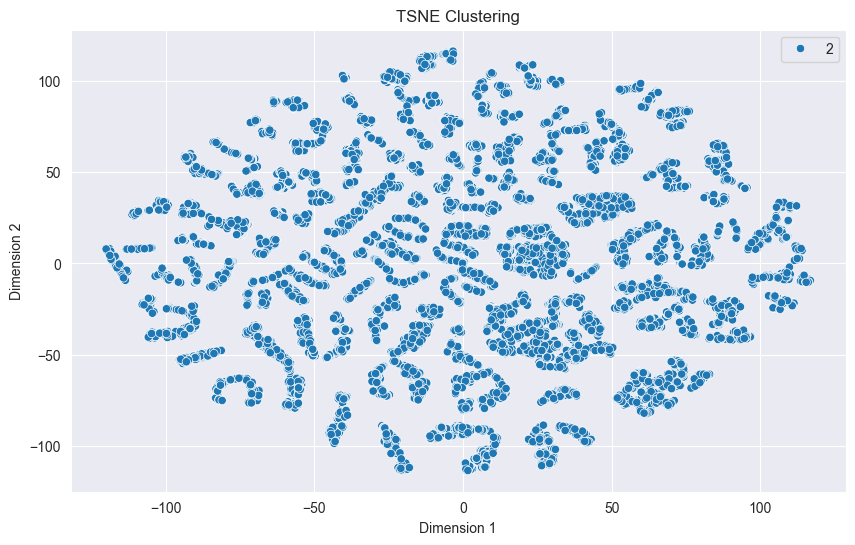

In [19]:
# Create a DataFrame for the TSNE data
data_encoded_tsne_df = pd.DataFrame(data=data_encoded_tsne, columns=['Dimension 1', 'Dimension 2'])

# Display the DataFrame
data_encoded_tsne_df

# plot the clusters
# Initialize the figure
plt.figure(figsize=(10, 6))

# Plot the clusters COLORED by kmeans labels
subset_labels = kmeans.labels_[:20000]
sns.scatterplot(x='Dimension 1', y='Dimension 2', data=data_encoded_tsne_df, hue=subset_labels, palette='tab10')

# Add labels
plt.title('TSNE Clustering')
plt.show()

C:\Users\Tao Groves\PycharmProjects\ml4va\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


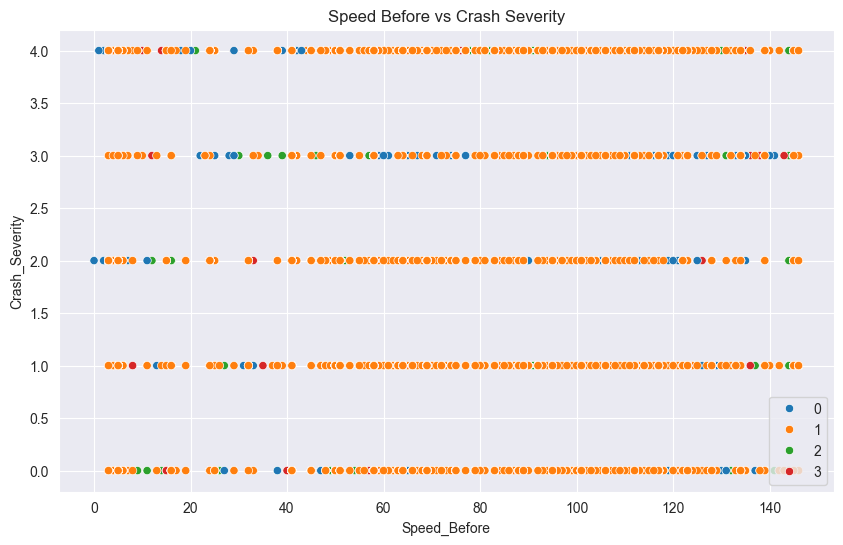

In [16]:
# scatter plot of Speed_Before vs Crash_Severity
# colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Speed_Before', y='Crash_Severity', data=data_encoded, hue=kmeans.labels_, palette='tab10')
plt.title('Speed Before vs Crash Severity')
plt.show()